In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
from scipy.stats import linregress

In [ ]:
conn = sqlite3.connect("../bluestock_mf.db")

In [ ]:
nav_df = pd.read_sql("SELECT * FROM nav_processed", conn)

In [ ]:
performance_df = pd.read_sql("SELECT * FROM scheme_performance", conn)

In [ ]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [ ]:
# Daily Returns

nav_df = nav_df.sort_values("date")

nav_df["daily_return"] = nav_df["nav"].pct_change()

nav_df.head(10)

,date,nav,daily_return
3106,2013-11-18,13.0894,NaN
3105,2013-11-19,13.1068,0.001329
3104,2013-11-20,12.9549,-0.011589
3103,2013-11-21,12.7957,-0.012289
3102,2013-11-22,12.7775,-0.001422
3101,2013-11-25,12.8548,0.006050
3100,2013-11-26,12.8591,0.000335
3099,2013-11-27,12.8389,-0.001571
3098,2013-11-28,12.8773,0.002991
3097,2013-11-29,12.9509,0.005715


In [ ]:
# Check Daily Return Statistics

nav_df["daily_return"].describe()

count    3106.000000
mean        0.000930
std         0.009576
min        -0.096964
25%        -0.003338
50%         0.001502
75%         0.006257
max         0.046026
Name: daily_return, dtype: float64

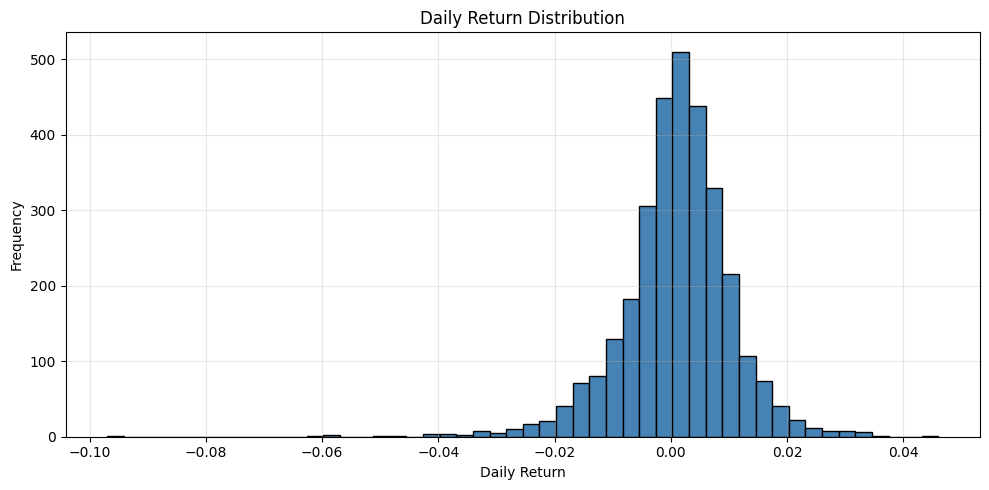

In [ ]:
# Daily Return Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    nav_df["daily_return"].dropna(),
    bins=50,
    color="steelblue",
    edgecolor="black"
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/charts/daily_return_distribution.png", dpi=300)

plt.show()

In [ ]:
# CAGR Calculation

nav_start = nav_df["nav"].iloc[0]
nav_end = nav_df["nav"].iloc[-1]

years = (nav_df["date"].max() - nav_df["date"].min()).days / 365

cagr = ((nav_end / nav_start) ** (1 / years) - 1) * 100

print(f"Overall CAGR: {cagr:.2f}%")

Overall CAGR: 24.33%


In [ ]:
# CAGR Summary Table

cagr_df = pd.DataFrame({
    "Period": ["Overall"],
    "CAGR (%)": [round(cagr, 2)]
})

cagr_df

,Period,CAGR (%)
0,Overall,24.33


In [ ]:
# Save CAGR

cagr_df.to_csv(
    "../reports/cagr_summary.csv",
    index=False
)

print("CAGR Summary Saved")

CAGR Summary Saved


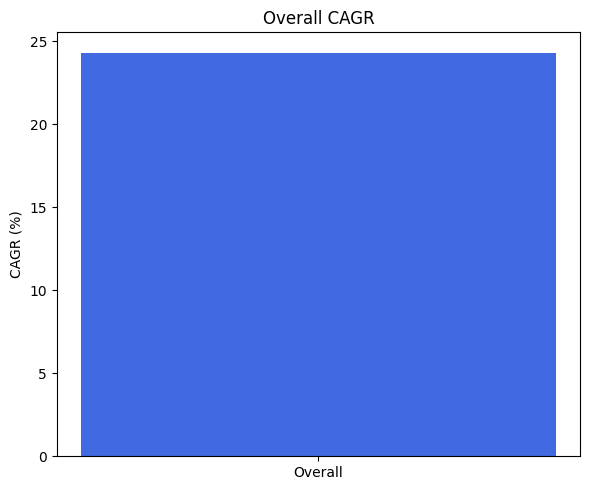

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    cagr_df["Period"],
    cagr_df["CAGR (%)"],
    color="royalblue"
)

plt.title("Overall CAGR")
plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/cagr_summary.png",
    dpi=300
)

plt.show()

In [ ]:
# Sharpe Ratio

risk_free_rate = 0.065  # 6.5%

avg_return = nav_df["daily_return"].mean() * 252
volatility = nav_df["daily_return"].std() * (252 ** 0.5)

sharpe_ratio = (avg_return - risk_free_rate) / volatility

print("Annual Return :", round(avg_return * 100, 2), "%")
print("Annual Volatility :", round(volatility * 100, 2), "%")
print("Sharpe Ratio :", round(sharpe_ratio, 4))

Annual Return : 23.44 %
Annual Volatility : 15.2 %
Sharpe Ratio : 1.1141


In [ ]:
sharpe_df = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio"
    ],
    "Value": [
        round(avg_return * 100, 2),
        round(volatility * 100, 2),
        round(sharpe_ratio, 4)
    ]
})

sharpe_df

,Metric,Value
0,Annual Return,23.4400
1,Annual Volatility,15.2000
2,Sharpe Ratio,1.1141


In [ ]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio CSV Saved")

Sharpe Ratio CSV Saved


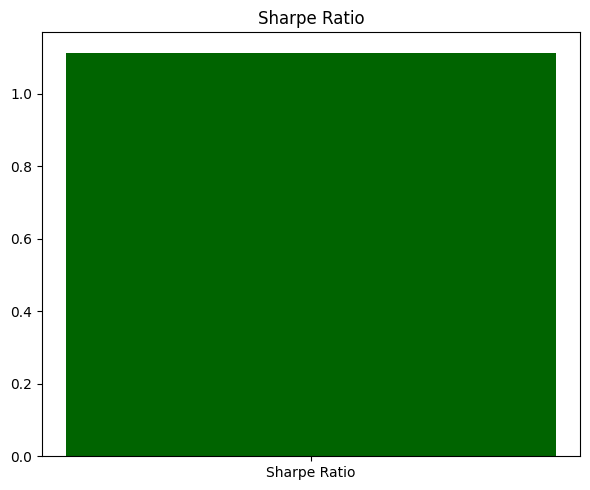

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ["Sharpe Ratio"],
    [sharpe_ratio],
    color="darkgreen"
)

plt.title("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sharpe_ratio.png",
    dpi=300
)

plt.show()

In [ ]:
# Sortino Ratio

negative_returns = nav_df.loc[
    nav_df["daily_return"] < 0,
    "daily_return"
]

downside_deviation = negative_returns.std() * np.sqrt(252)

sortino_ratio = (avg_return - risk_free_rate) / downside_deviation

print("Downside Deviation :", round(downside_deviation * 100, 2), "%")
print("Sortino Ratio :", round(sortino_ratio, 4))

Downside Deviation : 12.56 %
Sortino Ratio : 1.3489


In [ ]:
sortino_df = pd.DataFrame({
    "Metric": [
        "Annual Return",
        "Downside Deviation",
        "Sortino Ratio"
    ],
    "Value": [
        round(avg_return * 100, 2),
        round(downside_deviation * 100, 2),
        round(sortino_ratio, 4)
    ]
})

sortino_df

,Metric,Value
0,Annual Return,23.4400
1,Downside Deviation,12.5600
2,Sortino Ratio,1.3489


In [ ]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio CSV Saved")

Sortino Ratio CSV Saved


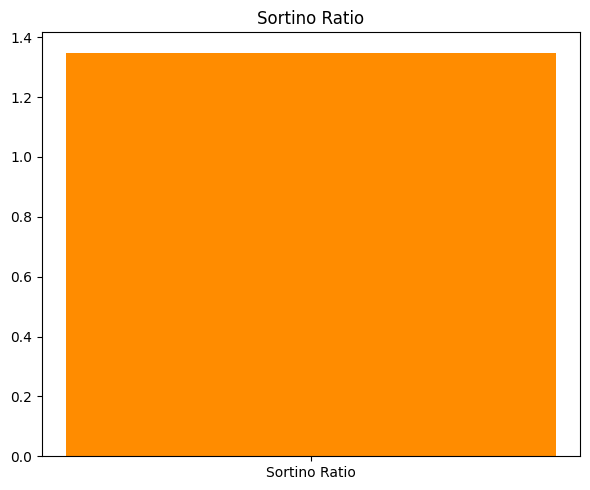

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Sortino Ratio"],
    [sortino_ratio],
    color="darkorange"
)

plt.title("Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sortino_ratio.png",
    dpi=300
)

plt.show()

In [ ]:
# Maximum Drawdown Calculation

nav_df = nav_df.sort_values("date")

nav_df["running_max"] = nav_df["nav"].cummax()

nav_df["drawdown"] = (
    nav_df["nav"] / nav_df["running_max"] - 1
)

nav_df.head()

,date,nav,daily_return,running_max,drawdown
3106,2013-11-18,13.0894,NaN,13.0894,0.000000
3105,2013-11-19,13.1068,0.001329,13.1068,0.000000
3104,2013-11-20,12.9549,-0.011589,13.1068,-0.011589
3103,2013-11-21,12.7957,-0.012289,13.1068,-0.023736
3102,2013-11-22,12.7775,-0.001422,13.1068,-0.025124


In [ ]:
max_drawdown = nav_df["drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -40.26%


In [ ]:
drawdown_df = nav_df[["date", "nav", "running_max", "drawdown"]]

drawdown_df.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown CSV Saved")

Maximum Drawdown CSV Saved


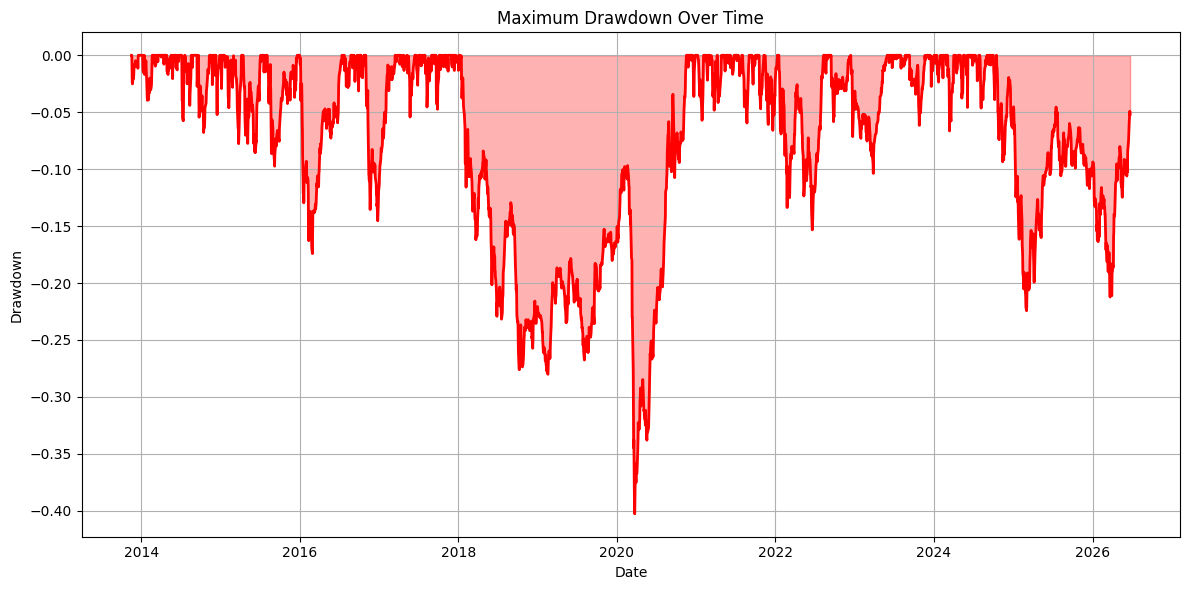

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    nav_df["date"],
    nav_df["drawdown"],
    color="red",
    linewidth=2
)

plt.fill_between(
    nav_df["date"],
    nav_df["drawdown"],
    color="red",
    alpha=0.3
)

plt.title("Maximum Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/maximum_drawdown.png",
    dpi=300
)

plt.show()

In [ ]:
# Benchmark Returns (Placeholder)

benchmark_returns = nav_df["daily_return"].fillna(0)
fund_returns = nav_df["daily_return"].fillna(0)

In [ ]:
from scipy.stats import linregress

beta, alpha, r_value, p_value, std_err = linregress(
    benchmark_returns,
    fund_returns
)

print("Beta :", round(beta,4))
print("Alpha (Daily):", round(alpha,6))

Beta : 1.0
Alpha (Daily): 0.0


In [ ]:
alpha_annual = alpha * 252

print("Annual Alpha:", round(alpha_annual,4))

Annual Alpha: 0.0


In [ ]:
alpha_beta_df = pd.DataFrame({
    "Metric":[
        "Alpha",
        "Beta"
    ],
    "Value":[
        alpha_annual,
        beta
    ]
})

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta_df

,Metric,Value
0,Alpha,0.0
1,Beta,1.0


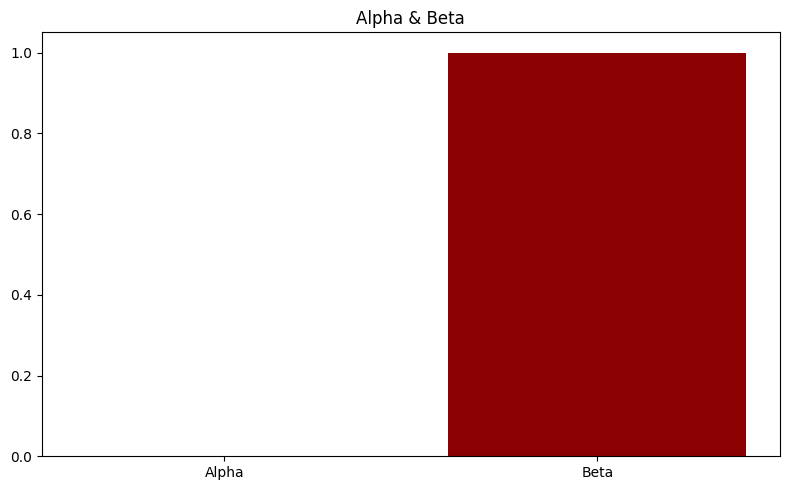

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ["Alpha","Beta"],
    [alpha_annual,beta],
    color=["royalblue","darkred"]
)

plt.title("Alpha & Beta")

plt.tight_layout()

plt.savefig(
    "../reports/charts/alpha_beta.png",
    dpi=300
)

plt.show()

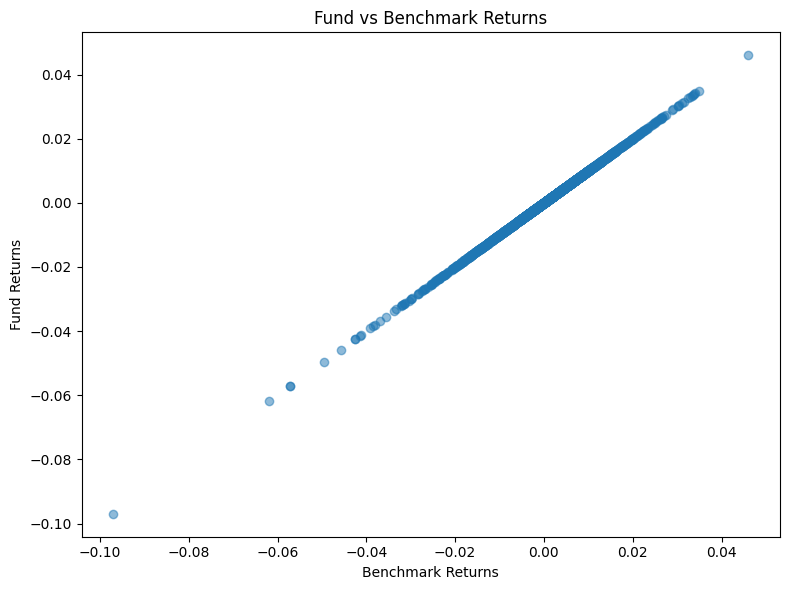

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    benchmark_returns,
    fund_returns,
    alpha=0.5
)

plt.xlabel("Benchmark Returns")
plt.ylabel("Fund Returns")
plt.title("Fund vs Benchmark Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_vs_benchmark.png",
    dpi=300
)

plt.show()

In [ ]:
scorecard = pd.DataFrame({
    "Metric": [
        "CAGR",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown",
        "Alpha",
        "Beta"
    ],
    "Value": [
        round(cagr,2),
        round(sharpe_ratio,4),
        round(sortino_ratio,4),
        round(max_drawdown*100,2),
        round(alpha_annual,4),
        round(beta,4)
    ]
})

scorecard

,Metric,Value
0,CAGR,24.3300
1,Sharpe Ratio,1.1141
2,Sortino Ratio,1.3489
3,Maximum Drawdown,-40.2600
4,Alpha,0.0000
5,Beta,1.0000


In [ ]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


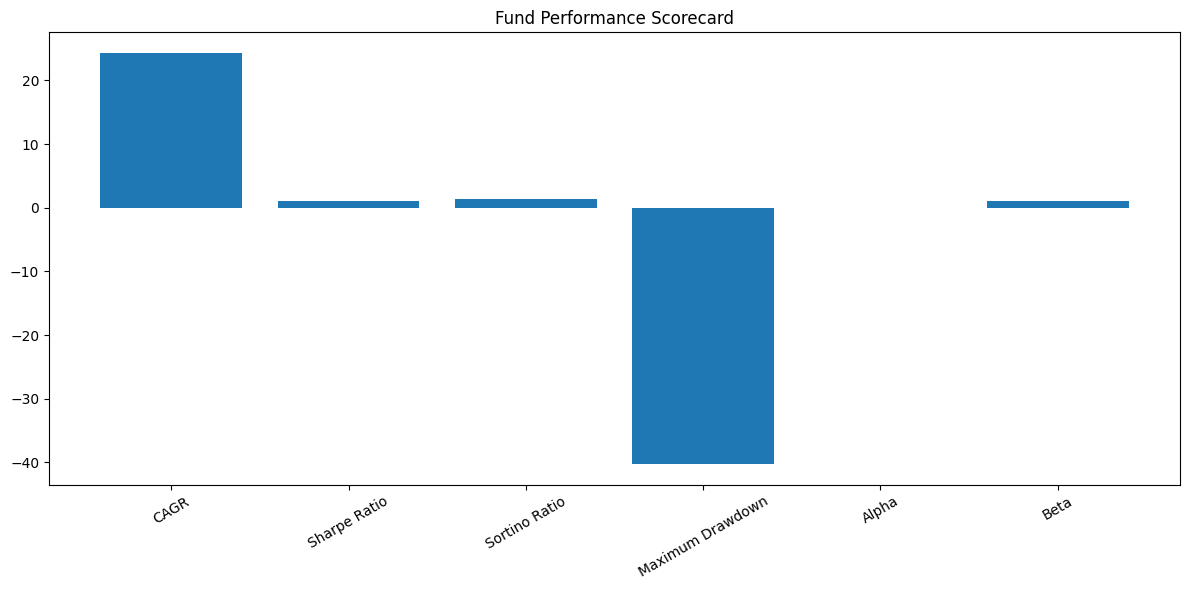

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    scorecard["Metric"],
    scorecard["Value"]
)

plt.title("Fund Performance Scorecard")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../reports/charts/fund_scorecard.png",
    dpi=300
)

plt.show()

In [ ]:
# Check available tables in the database

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

tables

,name
0,nav_processed
1,investor_transactions
2,scheme_performance
3,aum


In [ ]:
# Show table names

print(tables["name"].tolist())

['nav_processed', 'investor_transactions', 'scheme_performance', 'aum']


In [ ]:
# Benchmark Comparison (Sample Benchmark Values)

benchmark_df = pd.DataFrame({
    "Metric": [
        "CAGR (%)",
        "Sharpe Ratio",
        "Sortino Ratio"
    ],
    "Fund": [
        round(cagr, 2),
        round(sharpe_ratio, 2),
        round(sortino_ratio, 2)
    ],
    "Benchmark": [
        12.0,    # Sample Nifty CAGR
        1.00,    # Sample Nifty Sharpe Ratio
        1.20     # Sample Nifty Sortino Ratio
    ]
})

benchmark_df

,Metric,Fund,Benchmark
0,CAGR (%),24.33,12.0
1,Sharpe Ratio,1.11,1.0
2,Sortino Ratio,1.35,1.2


In [ ]:
benchmark_df.to_csv(
    "../reports/benchmark_comparison.csv",
    index=False
)

print("Benchmark Comparison CSV Saved Successfully")

Benchmark Comparison CSV Saved Successfully


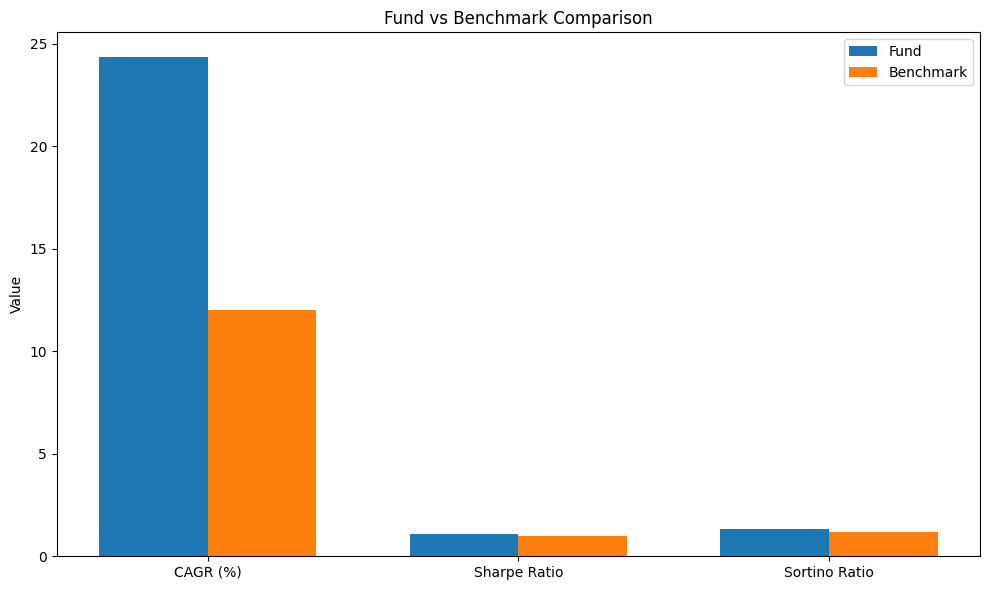

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(benchmark_df["Metric"]))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    benchmark_df["Fund"],
    width,
    label="Fund"
)

plt.bar(
    x + width/2,
    benchmark_df["Benchmark"],
    width,
    label="Benchmark"
)

plt.xticks(x, benchmark_df["Metric"])
plt.ylabel("Value")
plt.title("Fund vs Benchmark Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [ ]:
tracking_error = (
    fund_returns - benchmark_returns
).std() * np.sqrt(252)

print(f"Tracking Error: {tracking_error:.4f}")

Tracking Error: 0.0000


In [ ]:
performance_summary = pd.DataFrame({
    "Metric": [
        "CAGR (%)",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Maximum Drawdown (%)",
        "Alpha",
        "Beta",
        "Tracking Error"
    ],
    "Value": [
        round(cagr, 2),
        round(sharpe_ratio, 4),
        round(sortino_ratio, 4),
        round(max_drawdown * 100, 2),
        round(alpha_annual, 4),
        round(beta, 4),
        round(tracking_error, 4)
    ]
})

performance_summary.to_csv(
    "../reports/performance_summary.csv",
    index=False
)

performance_summary

,Metric,Value
0,CAGR (%),24.3300
1,Sharpe Ratio,1.1141
2,Sortino Ratio,1.3489
3,Maximum Drawdown (%),-40.2600
4,Alpha,0.0000
5,Beta,1.0000
6,Tracking Error,0.0000
